<a href="https://colab.research.google.com/github/BradyStonk/BradyStonk-Growth-Investing-System/blob/main/Growth_Investing_Backtester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1682/302486525.py:125: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


標的： GOOG
基準： QQQ
模式： BULL
期間： 2023-01-01 至 2024-12-31
Attack Signal 次數： 38


,Signal Date,Classification,Days Since First Signal,Entry Close,5D Avg Range %,Prior 20D Avg Range %,Stock 10D Return %,Benchmark 10D Return %,10D Relative Strength %,30D Stock Return %,...,180D Stock Return %,180D Simulated 2x Return %,180D Leverage Capture Ratio,180D Stock Max Drawdown %,180D Simulated 2x Max Drawdown %,365D Stock Return %,365D Simulated 2x Return %,365D Leverage Capture Ratio,365D Stock Max Drawdown %,365D Simulated 2x Max Drawdown %
0,2023-03-01,Attack Start,0,89.718964,1.662081,2.979378,-4.676157,-5.069275,0.393117,19.533780,...,50.679510,113.908619,1.123813,-12.914605,-25.157324,83.536440,200.428080,1.199645,-16.671860,-31.196289
1,2023-03-06,Continue,5,94.744667,2.039869,2.836308,1.046629,-0.378552,1.425181,9.981171,...,44.297969,96.268082,1.086597,-12.914605,-25.157324,72.554376,165.619587,1.141348,-16.671860,-31.196289
2,2023-03-24,Continue,23,105.133064,2.345301,2.496491,16.536641,7.908927,8.627714,2.055443,...,27.003590,52.353638,0.969383,-12.914605,-25.157324,43.600904,84.297950,0.966700,-21.037066,-38.595103
3,2023-03-28,Continue,27,100.474144,2.293578,2.579547,7.543774,3.438640,4.105134,10.773480,...,32.172446,65.182130,1.013012,-12.914605,-25.157324,48.360689,96.887874,1.001721,-22.279223,-40.527010
4,2023-04-11,Continue,41,105.192551,2.443110,2.735412,2.969152,2.289793,0.679359,16.179792,...,33.283067,68.193536,1.024448,-12.914605,-25.157324,54.043017,112.481034,1.040662,-22.279223,-40.527010
5,2023-04-24,Continue,54,105.846779,1.808255,2.238244,-0.158942,-0.604019,0.445077,19.788354,...,34.669420,71.856636,1.036311,-12.914605,-25.157324,58.244945,124.600024,1.069621,-22.279223,-40.527010
6,2023-05-18,Continue,78,122.440460,2.268169,2.357721,17.403268,6.673629,10.729639,-2.396352,...,17.721838,31.170639,0.879441,-12.914605,-25.157324,42.950601,83.992262,0.977777,-22.279223,-40.527010
7,2023-05-23,Continue,83,122.212486,2.420952,2.446959,14.220869,3.643792,10.577076,-2.554949,...,21.842816,40.569564,0.928671,-12.914605,-25.157324,38.777792,73.466974,0.947282,-22.279223,-40.527010
8,2023-07-27,Weak,148,128.734955,2.136784,2.227259,4.037470,-0.667279,4.704749,5.644124,...,20.374257,37.291815,0.915170,-14.389029,-27.620748,NaN,NaN,NaN,NaN,NaN
9,2023-08-03,Weak,155,127.644608,1.767559,2.088690,7.730299,-0.788302,8.518601,7.400783,...,22.660564,42.686293,0.941863,-14.389029,-27.620748,NaN,NaN,NaN,NaN,NaN



第一次 Attack： 2023-03-01
進場收盤： 89.719

30 個交易日後
正股報酬： 19.53 %
模擬 2x 報酬： 41.17 %
Capture Ratio： 1.053837549207379
正股最大回撤： -4.78 %
2x 最大回撤： -9.43 %

60 個交易日後
正股報酬： 37.39 %
模擬 2x 報酬： 84.71 %
Capture Ratio： 1.1328209951045092
正股最大回撤： -4.78 %
2x 最大回撤： -9.43 %

90 個交易日後
正股報酬： 30.05 %
模擬 2x 報酬： 64.44 %
Capture Ratio： 1.0720658308143471
正股最大回撤： -8.63 %
2x 最大回撤： -17.01 %

180 個交易日後
正股報酬： 50.68 %
模擬 2x 報酬： 113.91 %
Capture Ratio： 1.1238133381411324
正股最大回撤： -12.91 %
2x 最大回撤： -25.16 %

365 個交易日後
正股報酬： 83.54 %
模擬 2x 報酬： 200.43 %
Capture Ratio： 1.1996446067652007
正股最大回撤： -16.67 %
2x 最大回撤： -31.2 %


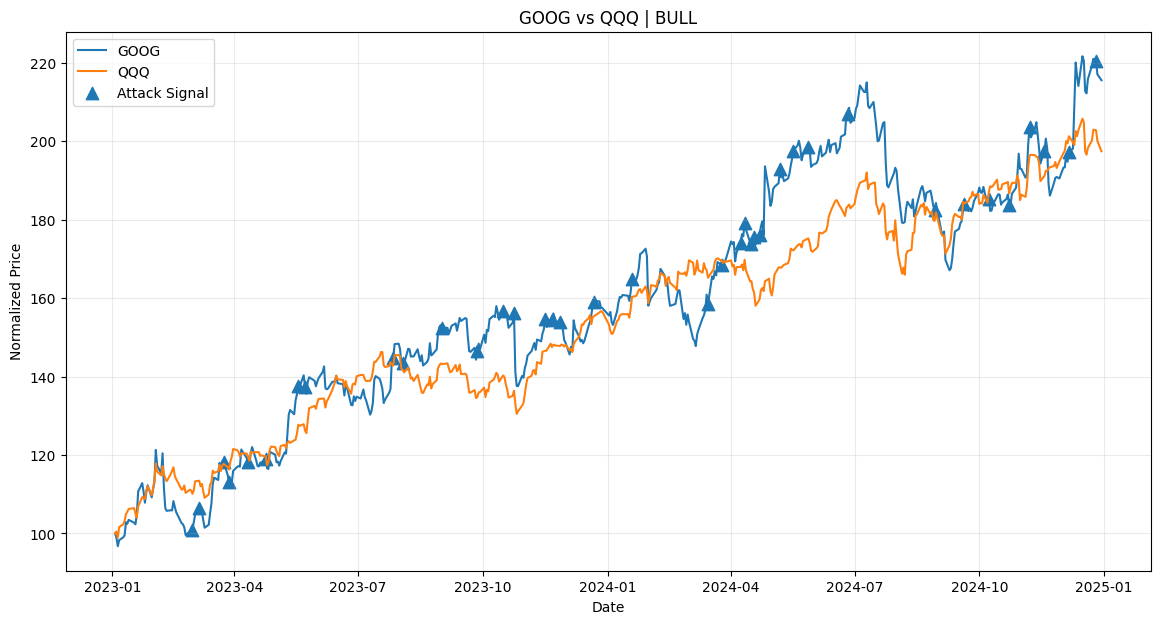

In [1]:
# 安裝套件
!pip -q install yfinance pandas matplotlib

import math
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display

# ==================================================
# 唯一設定區
# ==================================================

TICKER = "GOOG"
BENCHMARK = "QQQ"

MODE = "BULL"  # 改成 "BEAR" 可測熊市

BULL_START = "2023-01-01"
BULL_END = "2024-12-31"

BEAR_START = "2022-01-01"
BEAR_END = "2023-01-06"

RANGE_WINDOW = 5
PRIOR_RANGE_WINDOW = 20
RS_WINDOW = 10
SIGNAL_DECAY_DAYS = 90
HORIZONS = [30, 60, 90, 180, 365]

# ==================================================
# 函式
# ==================================================

def download_daily(ticker, start, end):
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False,
        actions=False,
    )

    if df.empty:
        raise RuntimeError(f"無法取得 {ticker} 歷史資料")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if "Adj Close" not in df.columns:
        df["Adj Close"] = df["Close"]

    return df.sort_index()


def prepare_data(stock, benchmark):
    s = stock[["High", "Low", "Close", "Adj Close"]].copy()
    s.columns = [
        "Stock High",
        "Stock Low",
        "Stock Close",
        "Stock Adj Close",
    ]

    b = benchmark[["Adj Close"]].copy()
    b.columns = ["Benchmark Adj Close"]

    df = s.join(b, how="inner").dropna().copy()

    df["Daily Range %"] = (
        (df["Stock High"] - df["Stock Low"])
        / df["Stock Close"]
        * 100
    )

    df["5D Avg Range %"] = (
        df["Daily Range %"]
        .rolling(RANGE_WINDOW)
        .mean()
    )

    df["Prior 20D Avg Range %"] = (
        df["Daily Range %"]
        .shift(RANGE_WINDOW)
        .rolling(PRIOR_RANGE_WINDOW)
        .mean()
    )

    df["Volatility Contraction"] = (
        df["5D Avg Range %"]
        < df["Prior 20D Avg Range %"]
    )

    df["Stock 10D Return %"] = (
        df["Stock Adj Close"]
        .pct_change(RS_WINDOW)
        * 100
    )

    df["Benchmark 10D Return %"] = (
        df["Benchmark Adj Close"]
        .pct_change(RS_WINDOW)
        * 100
    )

    df["10D Relative Strength %"] = (
        df["Stock 10D Return %"]
        - df["Benchmark 10D Return %"]
    )

    df["RS Strong"] = (
        df["10D Relative Strength %"] > 0
    )

    df["Attack Condition"] = (
        df["Volatility Contraction"]
        & df["RS Strong"]
    )

    previous = (
        df["Attack Condition"]
        .shift(1)
        .fillna(False)
        .astype(bool)
    )

    df["Attack Signal"] = (
        df["Attack Condition"] & ~previous
    )

    df["Stock Daily Return"] = (
        df["Stock Adj Close"]
        .pct_change()
        .fillna(0)
    )

    df["Simulated 2x Daily Return"] = (
        2 * df["Stock Daily Return"]
    )

    return df


def compound_return(series):
    return float((1 + series).prod() - 1)


def max_drawdown(series):
    wealth = (1 + series).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return float(drawdown.min())


def classify_signals(df):
    signal_dates = list(
        df.index[df["Attack Signal"]]
    )

    if not signal_dates:
        return pd.DataFrame()

    first_signal = signal_dates[0]
    rows = []

    for signal_date in signal_dates:
        age = (signal_date - first_signal).days

        if signal_date == first_signal:
            classification = "Attack Start"
        elif age <= SIGNAL_DECAY_DAYS:
            classification = "Continue"
        else:
            classification = "Weak"

        rows.append({
            "Signal Date": signal_date.strftime("%Y-%m-%d"),
            "Classification": classification,
            "Days Since First Signal": age,
            "Entry Close": float(
                df.loc[signal_date, "Stock Adj Close"]
            ),
            "5D Avg Range %": float(
                df.loc[signal_date, "5D Avg Range %"]
            ),
            "Prior 20D Avg Range %": float(
                df.loc[
                    signal_date,
                    "Prior 20D Avg Range %",
                ]
            ),
            "Stock 10D Return %": float(
                df.loc[
                    signal_date,
                    "Stock 10D Return %",
                ]
            ),
            "Benchmark 10D Return %": float(
                df.loc[
                    signal_date,
                    "Benchmark 10D Return %",
                ]
            ),
            "10D Relative Strength %": float(
                df.loc[
                    signal_date,
                    "10D Relative Strength %",
                ]
            ),
        })

    return pd.DataFrame(rows)


def add_forward_returns(events, df):
    if events.empty:
        return events

    result = events.copy()

    positions = {
        date.strftime("%Y-%m-%d"): i
        for i, date in enumerate(df.index)
    }

    for horizon in HORIZONS:
        stock_returns = []
        leverage_returns = []
        capture_ratios = []
        stock_drawdowns = []
        leverage_drawdowns = []

        for signal_date in result["Signal Date"]:
            start_pos = positions[signal_date]
            end_pos = start_pos + horizon

            if end_pos >= len(df):
                stock_returns.append(math.nan)
                leverage_returns.append(math.nan)
                capture_ratios.append(math.nan)
                stock_drawdowns.append(math.nan)
                leverage_drawdowns.append(math.nan)
                continue

            stock_series = df.iloc[
                start_pos + 1:end_pos + 1
            ]["Stock Daily Return"]

            leverage_series = df.iloc[
                start_pos + 1:end_pos + 1
            ]["Simulated 2x Daily Return"]

            stock_return = compound_return(stock_series)
            leverage_return = compound_return(
                leverage_series
            )

            if abs(stock_return) >= 0.05:
                capture = (
                    leverage_return
                    / (2 * stock_return)
                )
            else:
                capture = math.nan

            stock_returns.append(
                stock_return * 100
            )
            leverage_returns.append(
                leverage_return * 100
            )
            capture_ratios.append(capture)
            stock_drawdowns.append(
                max_drawdown(stock_series) * 100
            )
            leverage_drawdowns.append(
                max_drawdown(leverage_series) * 100
            )

        result[
            f"{horizon}D Stock Return %"
        ] = stock_returns

        result[
            f"{horizon}D Simulated 2x Return %"
        ] = leverage_returns

        result[
            f"{horizon}D Leverage Capture Ratio"
        ] = capture_ratios

        result[
            f"{horizon}D Stock Max Drawdown %"
        ] = stock_drawdowns

        result[
            f"{horizon}D Simulated 2x Max Drawdown %"
        ] = leverage_drawdowns

    return result


# ==================================================
# 執行
# ==================================================

MODE = MODE.upper().strip()

if MODE == "BULL":
    START_DATE = BULL_START
    END_DATE = BULL_END
elif MODE == "BEAR":
    START_DATE = BEAR_START
    END_DATE = BEAR_END
else:
    raise ValueError('MODE 只能填 "BULL" 或 "BEAR"')

stock = download_daily(
    TICKER,
    START_DATE,
    END_DATE,
)

benchmark = download_daily(
    BENCHMARK,
    START_DATE,
    END_DATE,
)

df = prepare_data(stock, benchmark)

events = classify_signals(df)
events = add_forward_returns(events, df)

print("標的：", TICKER)
print("基準：", BENCHMARK)
print("模式：", MODE)
print("期間：", START_DATE, "至", END_DATE)
print("Attack Signal 次數：", len(events))

display(events)

# ==================================================
# 摘要
# ==================================================

if MODE == "BULL":
    if events.empty:
        print("沒有 Attack Signal")
    else:
        first = events.iloc[0]

        print("\n第一次 Attack：", first["Signal Date"])
        print("進場收盤：", round(first["Entry Close"], 4))

        for horizon in HORIZONS:
            stock_col = (
                f"{horizon}D Stock Return %"
            )
            leverage_col = (
                f"{horizon}D Simulated 2x Return %"
            )
            capture_col = (
                f"{horizon}D Leverage Capture Ratio"
            )
            stock_dd_col = (
                f"{horizon}D Stock Max Drawdown %"
            )
            leverage_dd_col = (
                f"{horizon}D Simulated 2x Max Drawdown %"
            )

            if pd.notna(first.get(stock_col)):
                print(f"\n{horizon} 個交易日後")
                print(
                    "正股報酬：",
                    round(first[stock_col], 2),
                    "%",
                )
                print(
                    "模擬 2x 報酬：",
                    round(first[leverage_col], 2),
                    "%",
                )
                print(
                    "Capture Ratio：",
                    first[capture_col],
                )
                print(
                    "正股最大回撤：",
                    round(first[stock_dd_col], 2),
                    "%",
                )
                print(
                    "2x 最大回撤：",
                    round(first[leverage_dd_col], 2),
                    "%",
                )

else:
    stock_return = compound_return(
        df["Stock Daily Return"]
    )

    leverage_return = compound_return(
        df["Simulated 2x Daily Return"]
    )

    stock_mdd = max_drawdown(
        df["Stock Daily Return"]
    )

    leverage_mdd = max_drawdown(
        df["Simulated 2x Daily Return"]
    )

    print("\n熊市區間摘要")
    print(
        "正股區間報酬：",
        round(stock_return * 100, 2),
        "%",
    )
    print(
        "模擬 2x 區間報酬：",
        round(leverage_return * 100, 2),
        "%",
    )
    print(
        "正股最大回撤：",
        round(stock_mdd * 100, 2),
        "%",
    )
    print(
        "模擬 2x 最大回撤：",
        round(leverage_mdd * 100, 2),
        "%",
    )

# ==================================================
# 圖表
# ==================================================

normalized_stock = (
    df["Stock Adj Close"]
    / df["Stock Adj Close"].iloc[0]
    * 100
)

normalized_benchmark = (
    df["Benchmark Adj Close"]
    / df["Benchmark Adj Close"].iloc[0]
    * 100
)

plt.figure(figsize=(14, 7))

plt.plot(
    df.index,
    normalized_stock,
    label=TICKER,
)

plt.plot(
    df.index,
    normalized_benchmark,
    label=BENCHMARK,
)

signal_dates = df.index[
    df["Attack Signal"]
]

if len(signal_dates) > 0:
    plt.scatter(
        signal_dates,
        normalized_stock.loc[signal_dates],
        marker="^",
        s=80,
        label="Attack Signal",
    )

plt.title(
    f"{TICKER} vs {BENCHMARK} | {MODE}"
)

plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(alpha=0.25)
plt.legend()
plt.show()